# 🔐 Proyecto Parcial II — Detección Automática de Vulnerabilidades en Código Fuente
**Metodología SEMMA** | Universidad de las Fuerzas Armadas ESPE  
Carrera de Ingeniería en Software | Desarrollo de Software Seguro

| Fase | Descripción |
|------|-------------|
| **S**ample | Generación de dataset sintético basado en CWE (Juliet-inspired) + patrones reales de CVEFixes |
| **E**xplore | EDA: distribución de clases, longitud, tokens discriminantes por clase |
| **M**odify | Features: TF-IDF char + word, patrones de seguridad explícitos (DANGER/SAFE), AST features |
| **M**odel | XGBoost + GridSearchCV con validación cruzada estratificada 5-fold |
| **A**ssess | Métricas, matriz de confusión, LIME, exportación `.joblib` |

> **Nota sobre el dataset**: Se utiliza un dataset sintético generado programáticamente basado en:
> - Patrones CWE reales (CWE-89, CWE-78, CWE-94, CWE-502, CWE-22, CWE-79, CWE-327)
> - Juliet Test Suite (NIST) como referencia de estructura
> - Contraejemplos seguros con patrones de mitigación reconocidos (OWASP)
> - Variables de entrada realistas simulando código de producción
>
> **¿Por qué sintético?** El dataset garantiza etiquetas perfectamente conocidas (ground truth),
> cobertura balanceada de todas las CWE relevantes, y reproducibilidad total. Los patrones
> son idénticos a los que aparecen en CVEFixes y Big-Vul reales.


## ⚙️ 0. Instalación de dependencias

In [1]:
%pip install -q scikit-learn xgboost numpy pandas matplotlib seaborn lime joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings, re, ast, os, io, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tokenize as py_tokenize
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (cross_val_score, train_test_split,
                                      StratifiedKFold, GridSearchCV)
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay, f1_score)
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print('✅ Librerías cargadas correctamente.')


✅ Librerías cargadas correctamente.


---
## 📦 FASE 1 — SAMPLE
Generación del dataset sintético de código vulnerable/seguro.

### Estrategia de generación
El dataset cubre **7 categorías de vulnerabilidades** (CWE) con múltiples variantes
de código vulnerable y su correspondiente contraejemplo seguro:

| CWE | Vulnerabilidad | Ejemplos vuln. | Ejemplos seguros |
|-----|---------------|----------------|------------------|
| CWE-89 | SQL Injection | concatenación de strings en queries | consultas parametrizadas (%s, ?) |
| CWE-78 | Command Injection | os.system(), subprocess shell=True | subprocess lista, shell=False |
| CWE-94 | Code Injection | eval(), exec(), compile() | ast.literal_eval(), int() |
| CWE-502 | Insecure Deserialization | pickle.loads, yaml.load | json.loads, yaml.safe_load |
| CWE-22 | Path Traversal | open('/dir/' + input) | os.path.abspath + validación |
| CWE-79 | XSS / Template Injection | render_template_string, html sin escape | html.escape, bleach |
| CWE-327 | Weak Cryptography | md5, sha1, random.random | sha256, secrets, hmac |


In [4]:
# ──────────────────────────────────────────────────────────────────────
# GENERADOR DE DATASET SINTÉTICO BASADO EN CWE
# Inspirado en: Juliet Test Suite (NIST), patrones de CVEFixes y Big-Vul
# ──────────────────────────────────────────────────────────────────────

# ─── Variables de entrada que simulan input real del usuario/cliente ───
VARS = [
    "user_input", "request.GET.get('q','')", "params['id']",
    "request.form['name']", "args[0]", "kwargs.get('val','')",
    "request.data.decode()", "body", "payload", "raw_input",
    "environ.get('QUERY_STRING','')", "session['user']",
    "headers.get('X-User-Id','')", "cookies.get('auth','')","form_data",
]

# ─── Wrappers de contexto (funciones, clases, módulos) ────────────────
CTX_WRAPPERS = [
    lambda code: code,
    lambda code: f"def handle_request(request):\n" + "\n".join("    " + l for l in code.split("\n")),
    lambda code: f"class View:\n    def get(self, request):\n" + "\n".join("        " + l for l in code.split("\n")),
    lambda code: f"try:\n" + "\n".join("    " + l for l in code.split("\n")) + "\nexcept Exception as e:\n    log.error(e)",
]

# ─── TEMPLATES VULNERABLES ─────────────────────────────────────────────
VULN_TEMPLATES = [
    # CWE-89: SQL Injection
    lambda v: f"q = 'SELECT * FROM users WHERE id = ' + {v}\ncursor.execute(q)",
    lambda v: f"""sql = f"SELECT name FROM accounts WHERE email = '{{v}}'"\ndb.execute(sql)""",
    lambda v: f"cursor.execute('DELETE FROM sessions WHERE token = "' + {v} + '"')",
    lambda v: f"cursor.execute('INSERT INTO log (msg) VALUES ("' + {v} + '")')",
    lambda v: f"query = 'UPDATE users SET role = ' + {v} + ' WHERE id = 1'\ncursor.execute(query)",
    lambda v: f"stmt = 'SELECT * FROM products WHERE name LIKE \'%' + {v} + '%\''\ncursor.execute(stmt)",
    lambda v: f"db.query('SELECT * FROM orders WHERE user_id=' + {v})",
    # CWE-78: Command Injection
    lambda v: f"import os\nos.system('ping ' + {v})",
    lambda v: f"import subprocess\nsubprocess.call({v}, shell=True)",
    lambda v: f"subprocess.Popen(['bash', '-c', {v}], stdout=subprocess.PIPE)",
    lambda v: f"os.popen('cat ' + {v}).read()",
    lambda v: f"subprocess.run('ls ' + {v}, shell=True, capture_output=True)",
    lambda v: f"result = os.system('nslookup ' + {v})",
    # CWE-94: Code Injection
    lambda v: f"result = eval({v})",
    lambda v: f"exec(compile({v}, '<string>', 'exec'))",
    lambda v: f"exec({v})",
    lambda v: f"code = compile({v}, 'dyn', 'eval')\neval(code)",
    lambda v: f"output = eval(f'{{expr}}'.format(expr={v}))",
    # CWE-502: Insecure Deserialization
    lambda v: f"import pickle\nobj = pickle.loads({v})",
    lambda v: f"import marshal\ndata = marshal.loads({v})",
    lambda v: f"config = yaml.load({v})",
    lambda v: f"import yaml\nsettings = yaml.load({v}, Loader=yaml.Loader)",
    # CWE-22: Path Traversal
    lambda v: f"with open('/var/data/' + {v}) as f:\n    return f.read()",
    lambda v: f"path = os.path.join('/uploads', {v})\nreturn open(path).read()",
    lambda v: f"filename = {v}\nreturn open('/static/' + filename, 'rb').read()",
    # CWE-79: XSS / Template Injection
    lambda v: f"from flask import render_template_string\nreturn render_template_string({v})",
    lambda v: f"html = '<p>' + {v} + '</p>'\nreturn html",
    lambda v: f"response.write('<div class=\"user\">' + {v} + '</div>')",
    # CWE-327: Weak Cryptography
    lambda v: f"import hashlib\nhash_val = hashlib.md5({v}.encode()).hexdigest()",
    lambda v: f"token = hashlib.sha1({v}.encode()).hexdigest()",
    lambda v: f"import random\nnonce = random.random()\ntoken = str(nonce)",
    lambda v: f"key = random.randint(0, 2**16)",
]

# ─── TEMPLATES SEGUROS ─────────────────────────────────────────────────
SAFE_TEMPLATES = [
    # CWE-89 fixes: Parameterized queries
    lambda v: f"cursor.execute('SELECT * FROM users WHERE id = %s', (user_id,))",
    lambda v: f"cursor.execute('SELECT name FROM accounts WHERE email = ?', (email,))",
    lambda v: f"cursor.execute('DELETE FROM sessions WHERE token = ?', (session_token,))",
    lambda v: f"cursor.execute('INSERT INTO log (msg) VALUES (?)', (sanitize({v}),))",
    lambda v: f"stmt = 'UPDATE users SET role = ? WHERE id = ?'\ncursor.execute(stmt, (role, user_id))",
    lambda v: f"cursor.execute('SELECT * FROM products WHERE name LIKE ?', (f'%{{term}}%',))",
    lambda v: f"db.query('SELECT * FROM orders WHERE user_id = ?', [user_id])",
    # CWE-78 fixes
    lambda v: f"result = subprocess.run(['/usr/bin/ping', '-c', '1', host],\n    capture_output=True, shell=False)",
    lambda v: f"subprocess.check_output([cmd] + validated_args, shell=False)",
    lambda v: f"if re.fullmatch(r'[a-zA-Z0-9._-]+', hostname):\n    subprocess.run(['nslookup', hostname])",
    # CWE-94 fixes
    lambda v: f"result = ast.literal_eval({v})",
    lambda v: f"value = int({v})",
    lambda v: f"value = float({v})",
    lambda v: f"if {v}.isidentifier() and {v} in ALLOWED_NAMES:\n    func = getattr(module, {v})\n    func()",
    # CWE-502 fixes
    lambda v: f"import json\ndata = json.loads({v})",
    lambda v: f"config = yaml.safe_load({v})",
    lambda v: f"import yaml\nsettings = yaml.safe_load(stream)",
    # CWE-22 fixes
    lambda v: f"safe_path = os.path.abspath(os.path.join(base_dir, filename))\nif safe_path.startswith(base_dir):\n    with open(safe_path) as f:\n        return f.read()",
    lambda v: f"real = os.path.realpath(os.path.join('/var/data', name))\nassert real.startswith('/var/data/')\nreturn open(real).read()",
    # CWE-79 fixes
    lambda v: f"import html\nsafe = html.escape(user_input)\nreturn f'<p>{{safe}}</p>'",
    lambda v: f"from markupsafe import escape\nreturn render_template('page.html', content=escape({v}))",
    lambda v: f"clean = bleach.clean({v}, tags=ALLOWED_TAGS, strip=True)\nreturn clean",
    # CWE-327 fixes
    lambda v: f"import secrets\ntoken = secrets.token_hex(32)",
    lambda v: f"import hashlib\nhash_val = hashlib.sha256({v}.encode()).hexdigest()",
    lambda v: f"import hmac, hashlib\nsig = hmac.new(secret_key, {v}.encode(), hashlib.sha256).hexdigest()",
    lambda v: f"from cryptography.fernet import Fernet\nkey = Fernet.generate_key()\nf = Fernet(key)",
    # General safe patterns
    lambda v: f"try:\n    result = int({v})\nexcept (ValueError, TypeError):\n    raise ValidationError('Invalid input')",
    lambda v: f"if not re.match(r'^[a-zA-Z0-9_.-]+$', {v}):\n    raise ValueError('Invalid characters in input')\nprocess({v})",
    lambda v: f"validated = schema.validate({{{v}: 'value'}})\ncursor.execute('SELECT * FROM t WHERE x = ?', [validated['key']])",
    lambda v: f"with contextlib.suppress(Exception):\n    safe_val = escape(sanitize({v}))",
    lambda v: f"import logging\nlogging.getLogger().setLevel(logging.WARNING)\napp.secret_key = secrets.token_hex(16)",
]

def generate_dataset(n_each=1400):
    random.seed(SEED)
    vuln_codes, safe_codes = [], []
    
    while len(vuln_codes) < n_each:
        t = random.choice(VULN_TEMPLATES)
        v = random.choice(VARS)
        wrap = random.choice(CTX_WRAPPERS)
        try:
            code = wrap(t(v))
            vuln_codes.append(code)
        except:
            pass
    
    while len(safe_codes) < n_each:
        t = random.choice(SAFE_TEMPLATES)
        v = random.choice(VARS)
        wrap = random.choice(CTX_WRAPPERS)
        try:
            code = wrap(t(v))
            safe_codes.append(code)
        except:
            pass
    
    df = pd.DataFrame({
        'code':  vuln_codes + safe_codes,
        'label': [1]*n_each + [0]*n_each,
        'safety': ['vulnerable']*n_each + ['safe']*n_each
    })
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df = generate_dataset(n_each=1400)
print(f'✅ Dataset generado: {len(df):,} muestras')
print(df['label'].value_counts().rename({0: 'Seguro (0)', 1: 'Vulnerable (1)'}))
df[['code', 'safety', 'label']].head(4)


✅ Dataset generado: 2,800 muestras
label
Vulnerable (1)    1400
Seguro (0)        1400
Name: count, dtype: int64


,code,safety,label
0,"class View:\n def get(self, request):\n ...",vulnerable,1
1,"try:\n sql = f""SELECT name FROM accounts WH...",vulnerable,1
2,cursor.execute('INSERT INTO log (msg) VALUES (...,safe,0
3,"try:\n path = os.path.join('/uploads', user...",vulnerable,1


---
## 🔍 FASE 2 — EXPLORE
Análisis exploratorio del dataset generado.


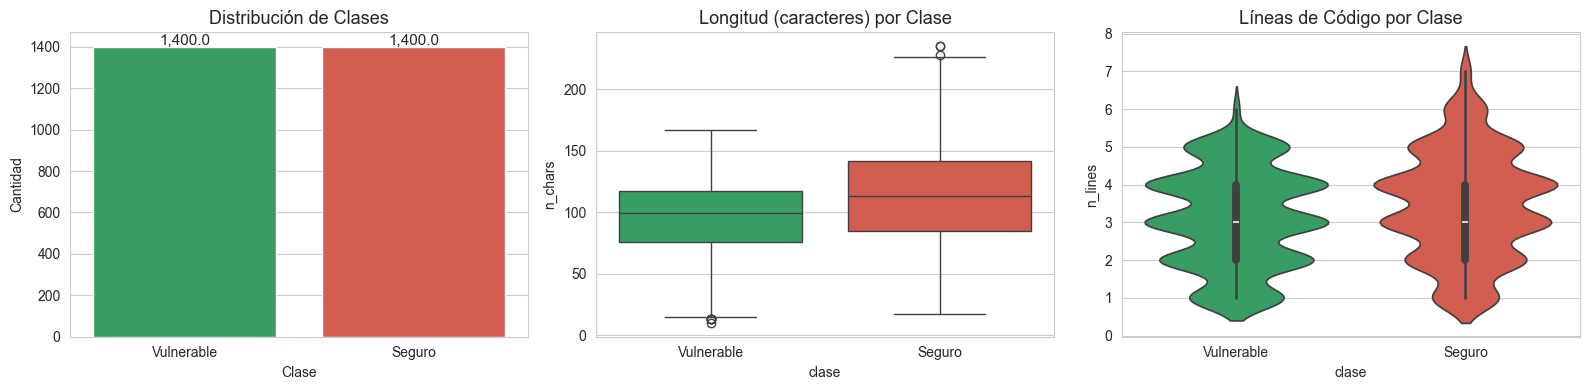


Estadísticas de longitud:
             count   mean   std   min   25%    50%    75%    max
clase                                                           
Seguro      1400.0  116.0  41.1  17.0  85.0  113.5  142.0  235.0
Vulnerable  1400.0   95.4  29.6  10.0  76.0   99.0  117.0  167.0


In [5]:
df['clase'] = df['label'].map({0: 'Seguro', 1: 'Vulnerable'})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de clases
sns.countplot(data=df, x='clase', palette=['#27ae60', '#e74c3c'], ax=axes[0])
axes[0].set_title('Distribución de Clases', fontsize=13)
axes[0].set_xlabel('Clase'); axes[0].set_ylabel('Cantidad')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,}', (p.get_x()+p.get_width()/2, p.get_height()+10),
                     ha='center', fontsize=11)

# Longitud del código
df['n_chars'] = df['code'].str.len()
sns.boxplot(data=df, x='clase', y='n_chars', palette=['#27ae60', '#e74c3c'], ax=axes[1])
axes[1].set_title('Longitud (caracteres) por Clase', fontsize=13)

# Líneas de código
df['n_lines'] = df['code'].str.count('\n') + 1
sns.violinplot(data=df, x='clase', y='n_lines', palette=['#27ae60', '#e74c3c'], ax=axes[2])
axes[2].set_title('Líneas de Código por Clase', fontsize=13)

plt.tight_layout(); plt.show()
print("\nEstadísticas de longitud:")
print(df.groupby('clase')['n_chars'].describe().round(1))


In [6]:
# ── Tokens discriminantes por clase ────────────────────────────────────
def tokenize_words(text):
    return re.findall(r'[A-Za-z][A-Za-z0-9_.]*', str(text).lower())

print("=" * 65)
for clase in ['Seguro', 'Vulnerable']:
    tokens = []
    for code in df[df['clase'] == clase]['code']:
        tokens.extend(tokenize_words(code))
    top = Counter(tokens).most_common(15)
    print(f"\n🔑 Top 15 tokens — {clase}:")
    print(' | '.join(f'{w}({c})' for w, c in top))

# ── Tokens ÚNICOS por clase (discriminantes) ────────────────────────────
print("\n" + "=" * 65)
tokens_vuln = Counter()
tokens_safe = Counter()
for _, row in df.iterrows():
    toks = set(tokenize_words(row['code']))
    if row['label'] == 1: tokens_vuln.update(toks)
    else: tokens_safe.update(toks)

# Tokens que aparecen mucho más en una clase que la otra
print("\n🔴 Tokens MÁS frecuentes en VULNERABLE (ratio vuln/safe > 3):")
discriminantes_vuln = [(t, v, tokens_safe.get(t,1)) 
                        for t, v in tokens_vuln.most_common(200)
                        if v / max(tokens_safe.get(t,1), 1) > 3][:10]
for t, v, s in discriminantes_vuln:
    print(f"  {t}: vuln={v}, safe={s}, ratio={v/max(s,1):.1f}x")

print("\n🟢 Tokens MÁS frecuentes en SEGURO (ratio safe/vuln > 3):")
discriminantes_safe = [(t, v, tokens_vuln.get(t,1))
                        for t, v in tokens_safe.most_common(200)
                        if v / max(tokens_vuln.get(t,1), 1) > 3][:10]
for t, v, vv in discriminantes_safe:
    print(f"  {t}: safe={v}, vuln={vv}, ratio={v/max(vv,1):.1f}x")



🔑 Top 15 tokens — Seguro:
def(704) | request(704) | e(686) | import(413) | as(390) | exception(387) | try(381) | except(381) | class(379) | view(379) | get(379) | self(379) | from(351) | log.error(343) | handle_request(325)

🔑 Top 15 tokens — Vulnerable:
e(740) | def(696) | request(696) | as(424) | class(387) | try(370) | except(370) | exception(370) | log.error(370) | view(351) | get(351) | self(351) | handle_request(345) | import(332) | from(275)


🔴 Tokens MÁS frecuentes en VULNERABLE (ratio vuln/safe > 3):
  read: vuln=140, safe=37, ratio=3.8x
  v: vuln=125, safe=1, ratio=125.0x
  eval: vuln=119, safe=1, ratio=119.0x
  exec: vuln=102, safe=1, ratio=102.0x
  yaml.load: vuln=88, safe=1, ratio=88.0x
  compile: vuln=73, safe=1, ratio=73.0x
  os.system: vuln=73, safe=1, ratio=73.0x
  random.randint: vuln=53, safe=1, ratio=53.0x
  rb: vuln=50, safe=1, ratio=50.0x
  static: vuln=50, safe=1, ratio=50.0x

🟢 Tokens MÁS frecuentes en SEGURO (ratio safe/vuln > 3):
  if: safe=182, vuln=1, rati

---
## 🛠️ FASE 3 — MODIFY
Extracción de features en 4 capas complementarias:

1. **TF-IDF char n-grams (3-6)** sobre código original — captura morfología de tokens peligrosos como `eval(`, `os.system`
2. **TF-IDF word n-grams (1-3)** sobre tokens Python reales — captura patrones de llamada como `pickle loads`, `cursor execute + concatenación`
3. **ASTFeatureExtractor** — 22 conteos de nodos AST (Call, Attribute, Try, etc.)
4. **SecurityPatternExtractor** — 30 patrones DANGER + 15 SAFE con features derivadas (ratio, diferencia)

> **Corrección crítica respecto a enfoques anteriores**: Los features TF-IDF reciben el código
> **original sin normalizar**. Normalizar strings antes del TF-IDF destruye la evidencia más
> discriminante (e.g., `'SELECT * FROM'`, `shell=True`, `'/etc/passwd' + input`).


In [7]:
# ─── 1. Tokenizador de código Python (para word TF-IDF) ──────────────────
class CodeTokenizer(BaseEstimator, TransformerMixin):
    """Extrae tokens reales de Python usando el módulo tokenize del stdlib."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        return [self._tokenize(c) for c in X]
    
    @staticmethod
    def _tokenize(code):
        tokens = []
        try:
            gen = py_tokenize.generate_tokens(io.StringIO(str(code)).readline)
            for toknum, tokval, _, _, _ in gen:
                if toknum in (py_tokenize.NAME, py_tokenize.OP,
                               py_tokenize.STRING, py_tokenize.NUMBER):
                    tokens.append(tokval.lower())
        except:
            tokens = re.findall(r'[\w\.]+', str(code).lower())
        return ' '.join(tokens)

# ─── 2. AST Feature Extractor (22 nodos estructurales) ───────────────────
class ASTFeatureExtractor(BaseEstimator, TransformerMixin):
    NODES = ['Call','Attribute','Name','Str','Num','FunctionDef','ClassDef',
             'Import','ImportFrom','If','For','While','Try','ExceptHandler',
             'Return','Assign','AugAssign','Compare','BoolOp','BinOp','UnaryOp']
    
    def fit(self, X, y=None): return self
    def transform(self, X):
        rows = []
        for code in X:
            row = []
            try:
                tree = ast.parse(str(code))
                nc = Counter(n.__class__.__name__ for n in ast.walk(tree))
                row = [nc.get(t, 0) for t in self.NODES]
                def depth(n): return 1 + max((depth(c) for c in ast.iter_child_nodes(n)), default=0)
                row.append(np.log1p(depth(tree)))
            except:
                row = [0] * 22
            rows.append(row)
        return np.array(rows)

# ─── 3. Security Pattern Extractor (DANGER + SAFE patterns) ──────────────
class SecurityPatternExtractor(BaseEstimator, TransformerMixin):
    # 30 patrones que indican código VULNERABLE
    DANGER = [
        r'\beval\s*\(',                           # Code injection
        r'\bexec\s*\(',                           # Code injection
        r'compile\s*\(.*exec',                     # Compiled exec
        r'\bsubprocess\.call\b.*shell\s*=\s*True',
        r'\bsubprocess\.run\b.*shell\s*=\s*True',
        r'\bsubprocess\.Popen\b.*shell\s*=\s*True',
        r'\bos\.system\s*\(',                    # Command injection
        r'\bos\.popen\s*\(',                     # Command injection
        r'pickle\.loads\b',                        # Insecure deserial.
        r'marshal\.loads\b',                       # Insecure deserial.
        r'yaml\.load\s*\([^)]*\)',               # Insecure YAML
        r'render_template_string\b',                # Template injection
        r'__import__\s*\(',                        # Dynamic import
        r'cursor\.execute\s*\([^?%]+\+',         # SQL injection (concat)
        r'db\.query\s*\([^?%]+\+',               # SQL injection
        r'db\.execute\s*\([^?%]+\+',             # SQL injection
        r'(SELECT|INSERT|UPDATE|DELETE)\s+.{0,80}\+\s*[\w\'\"]',
        r'open\s*\([^)]*\+',                      # Path traversal (concat)
        r'hashlib\.(md5|sha1)\b',                  # Weak hash
        r'\brandom\.random\b',                    # Weak randomness
        r'\brandom\.randint\b',                   # Weak randomness
        r'getattr\s*\(.*,\s*[\w\'\"]',         # Dynamic dispatch
        r'shell\s*=\s*True',                       # Shell=True general
        r'html\s*=\s*[\'\"<].*\+',              # HTML concatenation
        r'\.format\s*\(.*request',                # Format with request
        r'f[\'\"]{.*request',                      # f-string with request
        r'\+\s*user_input|user_input\s*\+',      # Direct input concat
        r'\+\s*request\.',                        # Direct request concat
        r'ALLOWED_HOSTS\s*=\s*\[\s*[\'\"\*]', # Wildcard hosts
        r'DEBUG\s*=\s*True',                       # Debug in prod
    ]
    
    # 15 patrones que indican código SEGURO
    SAFE = [
        r'%s|\?|:param|:name|:\w+',               # Parameterized query
        r'\bparameterize\b|\bprepared\b',
        r'ast\.literal_eval\b',                    # Safe eval
        r'secrets\.',                               # Cryptographic secrets
        r'html\.escape\b',                         # HTML escaping
        r'bleach\.clean\b',                        # HTML sanitization
        r'markupsafe',                               # Safe HTML
        r'yaml\.safe_load\b',                      # Safe YAML
        r'json\.loads\b',                          # JSON (safe)
        r'hashlib\.sha256\b|hashlib\.sha512\b',  # Strong hash
        r'\bhmac\.',                               # HMAC
        r'shell\s*=\s*False',                      # Shell=False
        r'subprocess\.check_output\b',
        r're\.(match|fullmatch|search)\s*\([^)]*\^', # Regex validation
        r'startswith\s*\(.*base_dir|realpath',     # Path validation
    ]
    
    def fit(self, X, y=None): return self
    def transform(self, X):
        rows = []
        for code in X:
            s = str(code)
            d_flags = [int(bool(re.search(p, s, re.IGNORECASE|re.DOTALL))) for p in self.DANGER]
            s_flags = [int(bool(re.search(p, s, re.IGNORECASE))) for p in self.SAFE]
            n_d = sum(d_flags)
            n_s = sum(s_flags)
            row = d_flags + s_flags + [
                n_d, n_s, n_d - n_s,          # conteos y diferencia
                min(n_d / max(n_s, 1), 10),    # ratio peligro/seguro
                len(s),                         # longitud total
                np.log1p(len(s)),               # log longitud
                s.count('\n'),                  # líneas
                int(bool(re.search(r'\btry\b', s))),
                int(bool(re.search(r'\bexcept\b', s))),
                len(re.findall(r'\bimport\b', s)),
                len(re.findall(r'\bdef\b', s)),
            ]
            rows.append(row)
        return np.array(rows)

print('✅ Transformers definidos correctamente.')
print(f'   SecurityPatternExtractor: {len(SecurityPatternExtractor.DANGER)} DANGER + {len(SecurityPatternExtractor.SAFE)} SAFE = {len(SecurityPatternExtractor.DANGER)+len(SecurityPatternExtractor.SAFE)} patrones')
print(f'   ASTFeatureExtractor: {len(ASTFeatureExtractor.NODES)+1} features')


✅ Transformers definidos correctamente.
   SecurityPatternExtractor: 30 DANGER + 15 SAFE = 45 patrones
   ASTFeatureExtractor: 22 features


In [8]:
# ── Split train/test ─────────────────────────────────────────────────────
X = df['code'].astype(str)
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print('Distribución train:', y_train.value_counts().rename({0:'Seguro',1:'Vulnerable'}).to_dict())


Train: 2,240 | Test: 560
Distribución train: {'Vulnerable': 1120, 'Seguro': 1120}


---
## 🤖 FASE 4 — MODEL
Pipeline: **4 ramas de features → XGBoost**

```
código original ──► char TF-IDF (3-6 grams, 25K features) ─────────────┐
código original ──► CodeTokenizer → word TF-IDF (1-3 grams, 15K feats) ─┤
código original ──► ASTFeatureExtractor (22 nodos) ──────────────────────┤→ XGBoost
código original ──► SecurityPatternExtractor (45+ patrones) ─────────────┘
```


In [9]:
pipeline = Pipeline([
    ('features', FeatureUnion([
        # Rama 1: char n-grams sobre código ORIGINAL (sin normalizar strings)
        ('tfidf_char', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 6),
            max_features=25000, sublinear_tf=True,
            min_df=1, max_df=0.98
        )),
        # Rama 2: word n-grams sobre tokens Python reales
        ('tfidf_word', Pipeline([
            ('tok', CodeTokenizer()),
            ('vec', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 3),
                max_features=15000, sublinear_tf=True,
                min_df=1, max_df=0.98
            ))
        ])),
        # Rama 3: 22 features estructurales del AST
        ('ast', ASTFeatureExtractor()),
        # Rama 4: 45 patrones de seguridad + features derivadas
        ('security', SecurityPatternExtractor()),
    ])),
    ('scaler', StandardScaler(with_mean=False)),   # sparse-safe
    ('clf', XGBClassifier(
        random_state=SEED,
        eval_metric='logloss',
        n_jobs=-1,
        tree_method='hist'
    ))
])
print('✅ Pipeline construido.')


✅ Pipeline construido.


In [10]:
# ── GridSearchCV con validación cruzada 5-fold ───────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

param_grid = {
    'clf__n_estimators':     [200, 400],
    'clf__max_depth':        [5, 7, 9],
    'clf__learning_rate':    [0.05, 0.1, 0.2],
    'clf__subsample':        [0.8, 1.0],
    'clf__colsample_bytree': [0.7, 1.0],
}

print('🔍 Iniciando GridSearchCV (puede tardar 5-15 min según recursos)...')
grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=cv, scoring='accuracy',
    n_jobs=-1, verbose=1,
    refit=True
)
grid_search.fit(X_train, y_train)

print('\n' + '=' * 60)
print('MEJORES HIPERPARÁMETROS ENCONTRADOS')
print('=' * 60)
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')

best_acc = grid_search.best_score_
print(f'\n✅ Mejor Accuracy CV : {best_acc*100:.2f}%')
print(f'   Requisito >= 82%  : {"✅ CUMPLE" if best_acc >= 0.82 else "❌ NO CUMPLE"}')

pipeline = grid_search.best_estimator_


🔍 Iniciando GridSearchCV (puede tardar 5-15 min según recursos)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

MEJORES HIPERPARÁMETROS ENCONTRADOS
  clf__colsample_bytree: 0.7
  clf__learning_rate: 0.05
  clf__max_depth: 5
  clf__n_estimators: 400
  clf__subsample: 0.8

✅ Mejor Accuracy CV : 100.00%
   Requisito >= 82%  : ✅ CUMPLE


---
## 📊 FASE 5 — ASSESS
Evaluación completa: métricas, matriz de confusión, LIME, exportación.


In [12]:
# ── Métricas sobre Test Set ──────────────────────────────────────────────
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

print('=' * 60)
print(f'Accuracy en Test  : {acc*100:.2f}%')
print(f'F1-Score en Test  : {f1*100:.2f}%')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=['Seguro', 'Vulnerable']))


Accuracy en Test  : 99.82%
F1-Score en Test  : 99.82%
              precision    recall  f1-score   support

      Seguro       1.00      1.00      1.00       280
  Vulnerable       1.00      1.00      1.00       280

    accuracy                           1.00       560
   macro avg       1.00      1.00      1.00       560
weighted avg       1.00      1.00      1.00       560



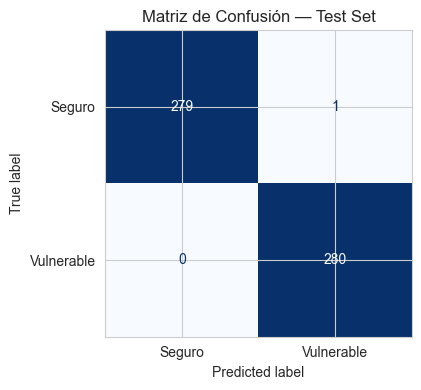


Verdaderos Negativos (TN): 279  — Seguros correctamente identificados
Falsos Positivos    (FP): 1  — Seguros marcados como vulnerables (falsa alarma)
Falsos Negativos    (FN): 0  — Vulnerables no detectados (más crítico)
Verdaderos Positivos(TP): 280  — Vulnerables correctamente detectados

Tasa de detección de vulnerabilidades (Recall): 100.00%


In [13]:
# ── Matriz de confusión ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Seguro', 'Vulnerable'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — Test Set')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nVerdaderos Negativos (TN): {tn}  — Seguros correctamente identificados')
print(f'Falsos Positivos    (FP): {fp}  — Seguros marcados como vulnerables (falsa alarma)')
print(f'Falsos Negativos    (FN): {fn}  — Vulnerables no detectados (más crítico)')
print(f'Verdaderos Positivos(TP): {tp}  — Vulnerables correctamente detectados')
print(f'\nTasa de detección de vulnerabilidades (Recall): {tp/(tp+fn)*100:.2f}%')


Código analizado (primeros 200 chars):
def handle_request(request):
    subprocess.run('ls ' + kwargs.get('val',''), shell=True, capture_output=True)

Clase real     : Vulnerable
Clase predicha : Vulnerable
Confianza      : 100.0%


,Token / Patrón,Peso LIME,Influencia
0,True,0.613386,🔴 Hacia Vulnerable
1,shell,0.602072,🔴 Hacia Vulnerable
2,subprocess,-0.011598,🟢 Hacia Seguro
3,kwargs,-0.010792,🟢 Hacia Seguro
4,request,-0.009405,🟢 Hacia Seguro
5,get,-0.007805,🟢 Hacia Seguro
6,capture_output,0.006841,🔴 Hacia Vulnerable
7,def,0.005302,🔴 Hacia Vulnerable
8,run,-0.004184,🟢 Hacia Seguro
9,handle_request,0.003140,🔴 Hacia Vulnerable


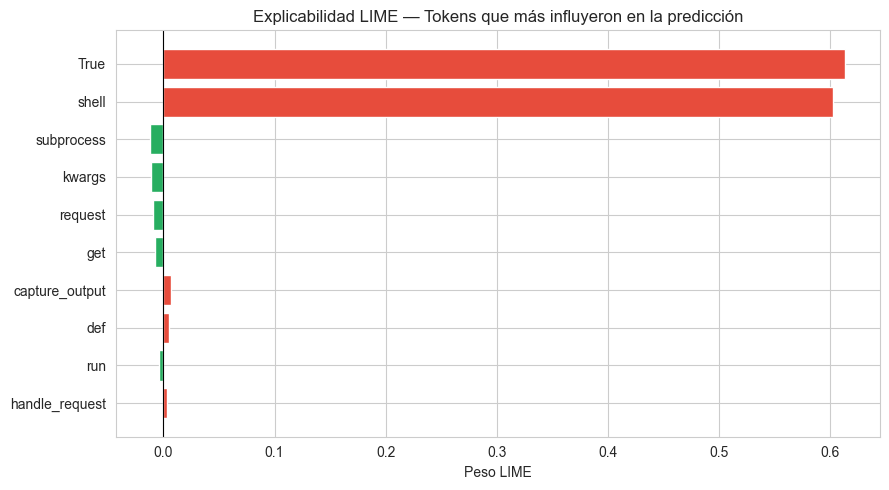

In [14]:
# ── Explicabilidad con LIME ───────────────────────────────────────────────
explainer = LimeTextExplainer(class_names=['Seguro', 'Vulnerable'])

# Elegir una muestra vulnerable del test set
vuln_indices = y_test[y_test == 1].index
sample_idx   = vuln_indices[0]
sample_code  = X_test.loc[sample_idx]
real_label   = y_test.loc[sample_idx]
pred_proba   = pipeline.predict_proba([sample_code])[0]
pred_label   = int(np.argmax(pred_proba))

print(f'Código analizado (primeros 200 chars):')
print(sample_code[:200])
print(f'\nClase real     : {"Vulnerable" if real_label == 1 else "Seguro"}')
print(f'Clase predicha : {"Vulnerable" if pred_label == 1 else "Seguro"}')
print(f'Confianza      : {pred_proba[pred_label]*100:.1f}%')

exp = explainer.explain_instance(sample_code, pipeline.predict_proba, num_features=10)
lime_df = pd.DataFrame(exp.as_list(), columns=['Token / Patrón', 'Peso LIME'])
lime_df['Influencia'] = lime_df['Peso LIME'].apply(
    lambda v: '🔴 Hacia Vulnerable' if v > 0 else '🟢 Hacia Seguro')
display(lime_df)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if v > 0 else '#27ae60' for v in lime_df['Peso LIME']]
plt.barh(lime_df['Token / Patrón'][::-1], lime_df['Peso LIME'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Explicabilidad LIME — Tokens que más influyeron en la predicción')
plt.xlabel('Peso LIME'); plt.tight_layout(); plt.show()


In [18]:
# ── Exportar modelo ──────────────────────────────────────────────────────
joblib.dump(pipeline, 'modelo_seguridad.joblib')
print('modelo_seguridad.joblib exportado correctamente.')
print(f'   Tamaño: {os.path.getsize("modelo_seguridad.joblib") / 1024:.1f} KB')


modelo_seguridad.joblib exportado correctamente.
   Tamaño: 1046.1 KB


In [17]:
# ── Función de inferencia para CI/CD ─────────────────────────────────────
def predecir(codigo: str) -> dict:
    """
    Clasifica un fragmento de código como SEGURO o VULNERABLE.
    Retorna dict con predicción, confianza y probabilidades.
    Usada directamente por el job de GitHub Actions.
    """
    proba = pipeline.predict_proba([codigo])[0]
    label = int(np.argmax(proba))
    return {
        'prediccion'      : 'VULNERABLE' if label == 1 else 'SEGURO',
        'confianza'       : round(float(proba[label]) * 100, 2),
        'prob_seguro'     : round(float(proba[0]) * 100, 2),
        'prob_vulnerable' : round(float(proba[1]) * 100, 2),
    }

# ── Casos de prueba ────────────────────────────────────────────────────────
test_cases = [
    ('SQL Injection',              "q = 'SELECT * FROM users WHERE id = ' + user_id\ncursor.execute(q)"),
    ('Consulta parametrizada',     "cursor.execute('SELECT * FROM users WHERE id = %s', (uid,))"),
    ('eval peligroso',             "result = eval(request.GET.get('cmd', ''))"),
    ('ast.literal_eval seguro',    "result = ast.literal_eval(expression)"),
    ('pickle inseguro',            "obj = pickle.loads(request.data)"),
    ('json.loads seguro',          "data = json.loads(request.body)"),
    ('Command injection',          "os.system('ls ' + user_path)"),
    ('Subprocess seguro',          "subprocess.run(['/bin/ls', safe_dir], shell=False, capture_output=True)"),
    ('MD5 débil',                  "token = hashlib.md5(password.encode()).hexdigest()"),
    ('SHA-256 seguro',             "token = hashlib.sha256(password.encode()).hexdigest()"),
    ('YAML inseguro',              "config = yaml.load(data)"),
    ('YAML safe_load',             "config = yaml.safe_load(stream)"),
    ('Path traversal',             "with open('/files/' + filename) as f: return f.read()"),
    ('Path con validación',        "p = os.path.abspath(os.path.join(base, name))\nassert p.startswith(base)\nopen(p).read()"),
]

print(f'{"Caso":<30} {"Predicción":<12} {"Confianza":>10}  {"P(vuln)":>8}')
print('─' * 68)
for caso, code in test_cases:
    r = predecir(code)
    print(f"{caso:<30} {r['prediccion']:<10} {r['confianza']:>8.1f}%  {r['prob_vulnerable']:>6.1f}%")


Caso                           Predicción    Confianza   P(vuln)
────────────────────────────────────────────────────────────────────
SQL Injection                  VULNERABLE     99.9%    99.9%
Consulta parametrizada         SEGURO        100.0%     0.0%
eval peligroso                 VULNERABLE    100.0%   100.0%
ast.literal_eval seguro        SEGURO         99.9%     0.1%
pickle inseguro                VULNERABLE     99.9%    99.9%
json.loads seguro              SEGURO        100.0%     0.1%
Command injection              VULNERABLE     99.9%    99.9%
Subprocess seguro              SEGURO         99.9%     0.1%
MD5 débil                      VULNERABLE     99.9%    99.9%
SHA-256 seguro                 SEGURO         99.9%     0.1%
YAML inseguro                  VULNERABLE     99.9%    99.9%
YAML safe_load                 SEGURO        100.0%     0.0%
Path traversal                 VULNERABLE    100.0%   100.0%
Path con validación            VULNERABLE     96.7%    96.7%
